In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
data_dir = Path("../model_outputs")

ds_r1  = xr.open_dataset(data_dir / "tas_Amon_MPI-ESM1-2-LR_historical-ssp245_r1i1p1f1_g025_185001-210012.nc")
ds_r25 = xr.open_dataset(data_dir / "tas_Amon_MPI-ESM1-2-LR_historical-ssp245_r25i1p1f1_g025_185001-210012.nc")
ds_pic = xr.open_dataset(data_dir / "tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc")

# --- Area-weighted global mean ---
# Grid cells near the equator are larger than near the poles,
# so we weight each latitude by cos(lat) before averaging.
def global_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    return ds["tas"].weighted(weights).mean(dim=["lat", "lon"])

gm_r1  = global_mean(ds_r1)
gm_r25 = global_mean(ds_r25)
gm_pic = global_mean(ds_pic)

# Convert from Kelvin to Celsius
gm_r1  = gm_r1  - 273.15
gm_r25 = gm_r25 - 273.15
gm_pic = gm_pic - 273.15

# --- Annual mean (resample monthly → yearly) ---
gm_r1_ann  = gm_r1.resample(time="YE").mean()
gm_r25_ann = gm_r25.resample(time="YE").mean()
gm_pic_ann = gm_pic.resample(time="YE").mean()


/var/folders/pb/g2p0r0dj2y14qj_mw3_0cntr0000gn/T/ipykernel_75318/2972550991.py:5: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pic = xr.open_dataset(data_dir / "tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc")
/var/folders/pb/g2p0r0dj2y14qj_mw3_0cntr0000gn/T/ipykernel_75318/2972550991.py:5: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pic = xr.open_dataset(data_dir / "tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc")
/var/folders/pb/g2p0r0dj2y14qj_mw3_0cntr0000gn/T/ipykernel_75318/2972550991.py:5: SerializationWarning: Unable

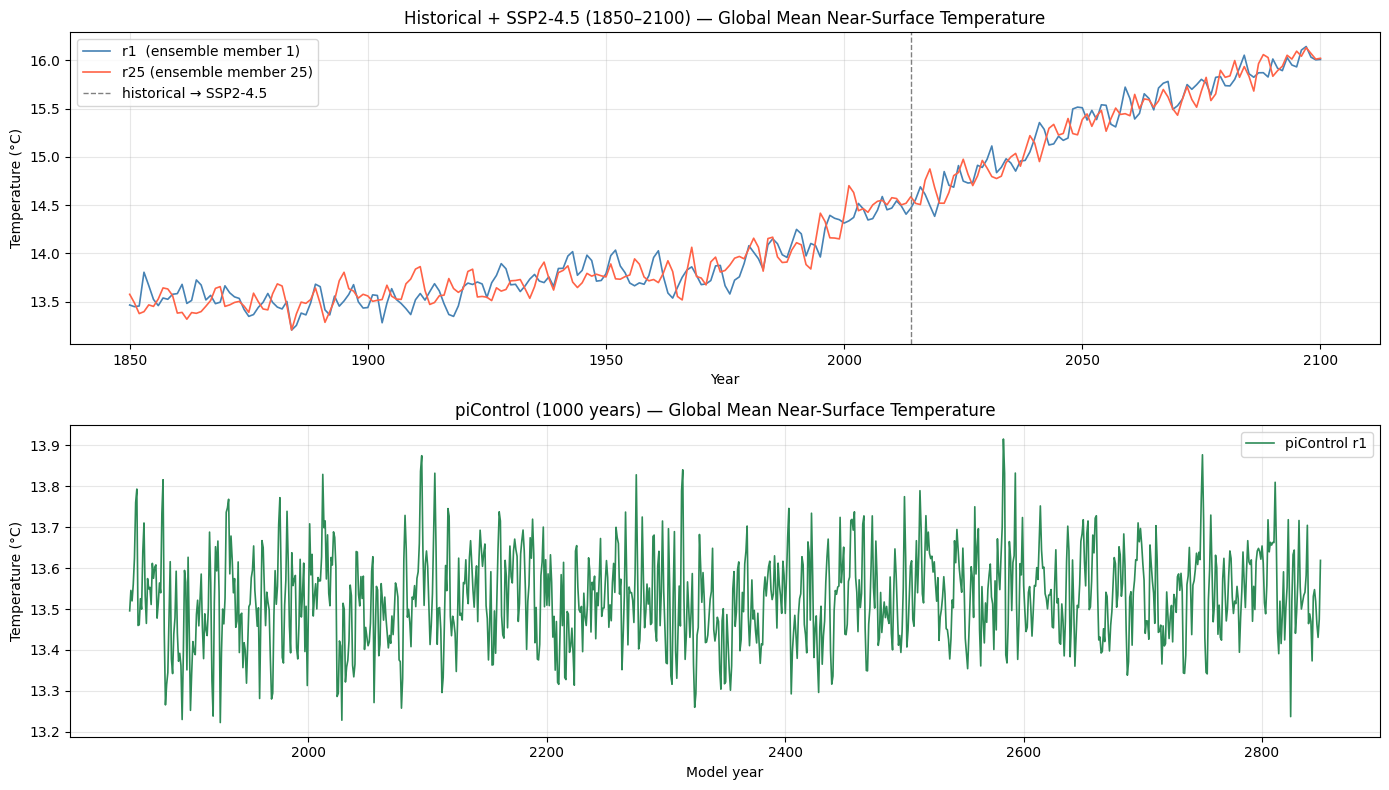

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# --- Top panel: historical + SSP245 (r1 and r25) ---
ax = axes[0]
ax.plot(gm_r1_ann.time.dt.year,  gm_r1_ann.values,  color="steelblue",  lw=1.2, label="r1  (ensemble member 1)")
ax.plot(gm_r25_ann.time.dt.year, gm_r25_ann.values, color="tomato",     lw=1.2, label="r25 (ensemble member 25)")
ax.axvline(2014, color="gray", lw=1, linestyle="--", label="historical → SSP2-4.5")
ax.set_title("Historical + SSP2-4.5 (1850–2100) — Global Mean Near-Surface Temperature")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(alpha=0.3)

# --- Bottom panel: piControl ---
ax = axes[1]
ax.plot(gm_pic_ann.time.dt.year, gm_pic_ann.values, color="seagreen", lw=1.2, label="piControl r1")
ax.set_title("piControl (1000 years) — Global Mean Near-Surface Temperature")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Model year")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("global_mean_tas_timeseries.png", dpi=150)
plt.show()
